First 5 Rows
   EmployeeID     Name   Age  Gender Department        Salary  Experience
0         101    Alice  25.0  Female         HR  45000.000000         2.0
1         102      Bob  30.0    Male         IT  60000.000000         5.0
2         103  Charlie  29.5    Male    Finance  55000.000000         4.0
3         104    David  28.0    Male         IT  56909.090909         3.0
4         105      Eva  26.0  Female         HR  47000.000000         2.0

Dataset Shape
(12, 7)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 12
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  12 non-null     int64  
 1   Name        12 non-null     object 
 2   Age         12 non-null     float64
 3   Gender      12 non-null     object 
 4   Department  12 non-null     object 
 5   Salary      12 non-null     float64
 6   Experience  12 non-null     float64
dtypes: float64(3), int64(1), obj

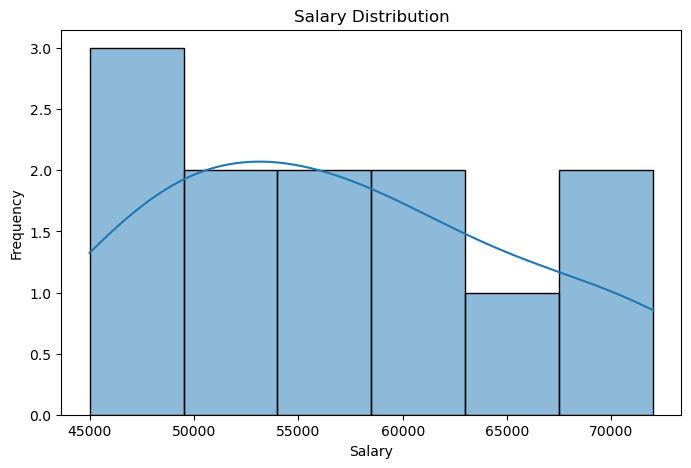

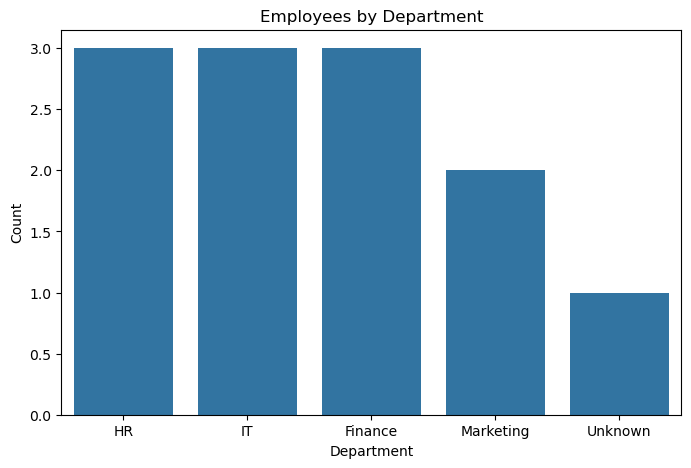

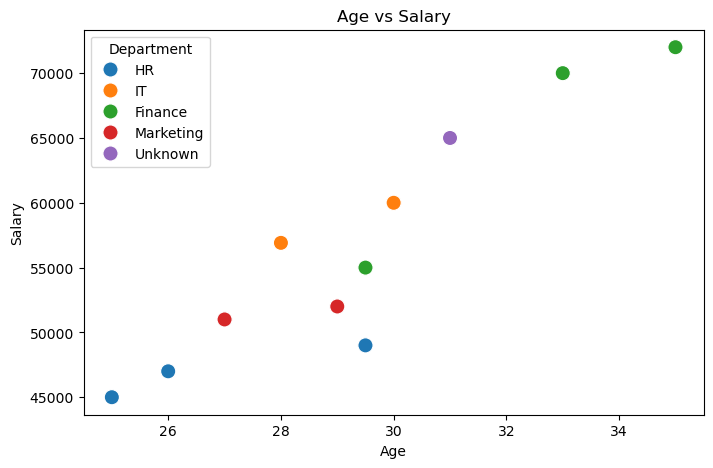


Correlation Matrix
            EmployeeID       Age    Salary  Experience
EmployeeID    1.000000  0.467775  0.409646    0.240496
Age           0.467775  1.000000  0.921341    0.864047
Salary        0.409646  0.921341  1.000000    0.838597
Experience    0.240496  0.864047  0.838597    1.000000

Possible Salary Outliers
Empty DataFrame
Columns: [EmployeeID, Name, Age, Gender, Department, Salary, Experience]
Index: []

EDA Completed Successfully


In [1]:
# ==========================================
# Exploratory Data Analysis (EDA)
# CodeOrbit Internship Task 2
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------
# Load Dataset
# ---------------------------------

df = pd.read_csv(r"C:\Users\singh\Downloads\employee_data.csv")

# ---------------------------------
# Data Cleaning
# ---------------------------------

df.drop_duplicates(inplace=True)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")
df["Experience"] = pd.to_numeric(df["Experience"], errors="coerce")

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())
df["Experience"] = df["Experience"].fillna(df["Experience"].median())
df["Department"] = df["Department"].fillna("Unknown")

# Save cleaned dataset
df.to_csv("employee_cleaned.csv", index=False)

# ---------------------------------
# Dataset Overview
# ---------------------------------

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDepartment Counts")
print(df["Department"].value_counts())

print("\nGender Counts")
print(df["Gender"].value_counts())

# ---------------------------------
# Visualization 1: Histogram
# ---------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["Salary"], bins=6, kde=True)

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.savefig("histogram_salary.png")

plt.show()

# ---------------------------------
# Visualization 2: Bar Chart
# ---------------------------------

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Department")

plt.title("Employees by Department")

plt.xlabel("Department")

plt.ylabel("Count")

plt.savefig("department_bar_chart.png")

plt.show()

# ---------------------------------
# Visualization 3: Scatter Plot
# ---------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="Age",
                y="Salary",
                hue="Department",
                s=120)

plt.title("Age vs Salary")

plt.savefig("age_salary_scatter.png")

plt.show()

# ---------------------------------
# Correlation
# ---------------------------------

print("\nCorrelation Matrix")

print(df.corr(numeric_only=True))

# ---------------------------------
# Outlier Detection
# ---------------------------------

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["Salary"] < Q1 - 1.5 * IQR) |
    (df["Salary"] > Q3 + 1.5 * IQR)
]

print("\nPossible Salary Outliers")

print(outliers)

print("\nEDA Completed Successfully")